In [2]:
%pip install matplotlib numpy scipy networkx tqdm

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\antoi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import os
import sys

# Navigate up one directory level to access src/
sys.path.append(os.path.abspath("../"))

import matplotlib.pyplot as plt
import numpy as np
from src.environments import SingleCampaignEnv
from src.learners import UCBLearner

In [4]:
# Discretize budget from 0 to 100 with steps of 5 (21 arms total)
budgets = np.arange(0, 105, 5)

# Initialize environment with the budget space
env = SingleCampaignEnv(budgets=budgets, sigma=2)

# Initialize UCB learner with 21 arms
learner = UCBLearner(n_arms=len(budgets))

# Time horizon: 1 year of daily allocations
T = 365

# Arrays to collect tracking metrics
pulled_arms = []
rewards = []

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

for t in range(T):
    # 1. Policy selects arm maximizing empirical_mean + confidence_bound
    arm = learner.pull_arm()

    # 2. Environment returns a noisy sample from the true reward curve
    reward = env.round(arm)

    # 3. Learner increments time, pull count, and refines the mean/bound
    learner.update(arm, reward)

    # Log metrics
    pulled_arms.append(arm)
    rewards.append(reward)

print(f"Simulation completed for T={T} days.")
print(f"Most pulled arm index: {max(set(pulled_arms), key=pulled_arms.count)}")
print(f"Corresponding budget allocated: {budgets[max(set(pulled_arms), key=pulled_arms.count)]} EUR")

Simulation completed for T=365 days.
Most pulled arm index: 20
Corresponding budget allocated: 100 EUR


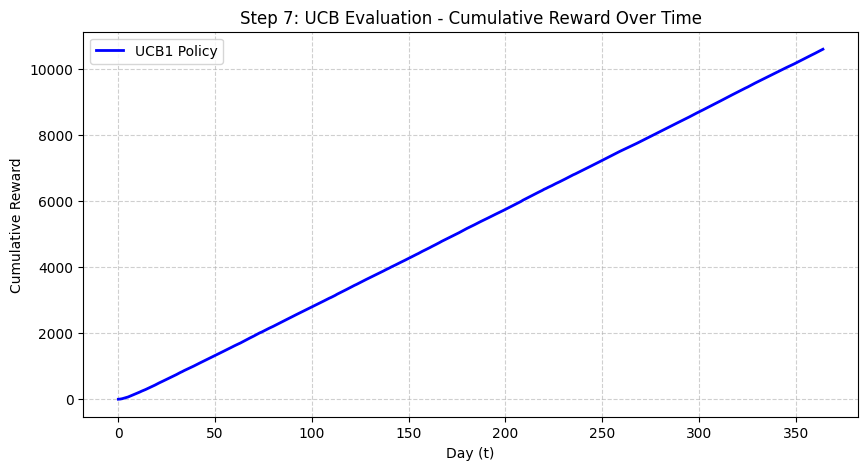

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(rewards), label="UCB1 Policy", color="blue", lw=2)
plt.xlabel("Day (t)")
plt.ylabel("Cumulative Reward")
plt.title("Step 7: UCB Evaluation - Cumulative Reward Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

Clairvoyant Optimal Arm Index: 20
Optimal Budget Allocation: 100 EUR
Expected Expected Daily Reward: 29.4505


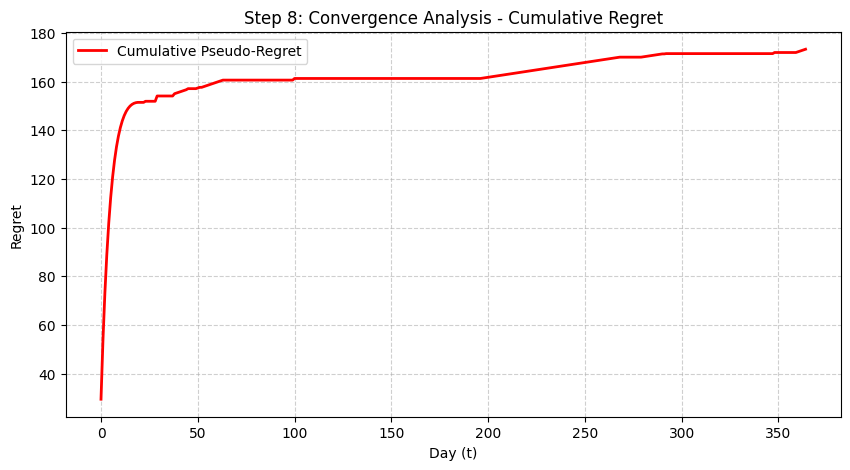

In [7]:
# Identify the true optimal arm using latent environment means
optimal_arm = np.argmax(env.means)
optimal_reward = env.means[optimal_arm]

print(f"Clairvoyant Optimal Arm Index: {optimal_arm}")
print(f"Optimal Budget Allocation: {budgets[optimal_arm]} EUR")
print(f"Expected Expected Daily Reward: {optimal_reward:.4f}")

# Calculate true regret at each time step
# Note: Using env.means[pulled_arms] computes pseudo-regret (filters out noise variance)
daily_regret = optimal_reward - env.means[pulled_arms]
cumulative_regret = np.cumsum(daily_regret)

# Plotting Cumulative Regret
plt.figure(figsize=(10, 5))
plt.plot(cumulative_regret, label="Cumulative Pseudo-Regret", color="red", lw=2)
plt.xlabel("Day (t)")
plt.ylabel("Regret")
plt.title("Step 8: Convergence Analysis - Cumulative Regret")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()